In [1]:
!pip install shap lime --quiet
!pip install xgboost optuna tqdm --quiet
!pip install scikit-learn --upgrade --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 18.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 82.9 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna
from tqdm.notebook import tqdm
import seaborn as sns
from sklearn.model_selection import train_test_split,cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             roc_auc_score, roc_curve,ConfusionMatrixDisplay)
from xgboost import XGBClassifier

import shap
from lime.lime_tabular import LimeTabularExplainer
import warnings
warnings.filterwarnings("ignore")
sns.set(style="whitegrid", palette="muted")

#Before Renaming Cols

In [3]:
df2=pd.read_csv("german_credit_data.csv")
df2.sample(5)

,laufkont,laufzeit,moral,verw,hoehe,sparkont,beszeit,rate,famges,buerge,...,verm,alter,weitkred,wohn,bishkred,beruf,pers,telef,gastarb,kredit
200,4,30,2,3,2333,3,5,4,3,1,...,3,30,1,2,1,4,2,1,2,1
902,2,36,3,0,2225,1,5,4,3,1,...,4,57,1,3,2,3,2,2,2,0
586,1,18,4,0,5302,1,5,2,3,1,...,4,36,3,3,3,4,2,2,2,1
289,4,15,3,3,1478,1,3,4,4,1,...,1,33,1,2,2,3,2,1,2,1
347,3,10,4,0,781,1,5,4,3,1,...,4,63,3,3,2,3,2,2,2,1


In [ ]:
df2.isna().sum()

,0
laufkont,0
laufzeit,0
moral,0
verw,0
hoehe,0
sparkont,0
beszeit,0
rate,0
famges,0
buerge,0


In [ ]:
df2["kredit"].value_counts(normalize=True) * 100


,proportion
kredit,
1,70.0
0,30.0


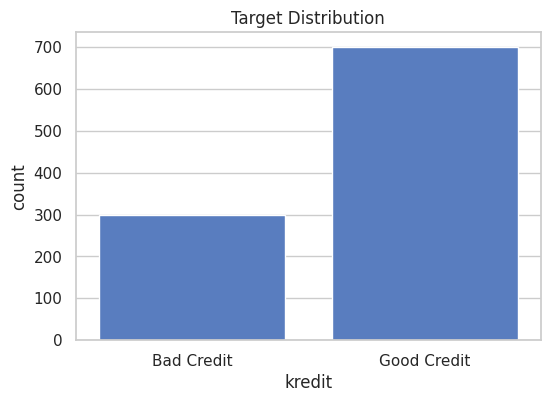

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x="kredit", data=df2)
plt.xticks([0,1], ["Bad Credit", "Good Credit"])
plt.title("Target Distribution")
plt.show()


#''AFTER RENAMING COLS''

In [4]:
cols = ["Status", "Duration", "CreditHistory", "Purpose", "CreditAmount", "Savings",
        "Employment", "InstallmentRate", "PersonalStatusSex", "Debtors", "ResidenceSince",
        "Property", "Age", "InstallmentPlans", "Housing", "ExistingCredits", "Job",
        "NumLiable", "Telephone", "ForeignWorker", "Target"]

In [5]:
df = pd.read_csv("german_credit_data.csv", sep=',', header=0, names=cols)

In [6]:
df.head()

,Status,Duration,CreditHistory,Purpose,CreditAmount,Savings,Employment,InstallmentRate,PersonalStatusSex,Debtors,...,Property,Age,InstallmentPlans,Housing,ExistingCredits,Job,NumLiable,Telephone,ForeignWorker,Target
0,1,18,4,2,1049,1,2,4,2,1,...,2,21,3,1,1,3,2,1,2,1
1,1,9,4,0,2799,1,3,2,3,1,...,1,36,3,1,2,3,1,1,2,1
2,2,12,2,9,841,2,4,2,2,1,...,1,23,3,1,1,2,2,1,2,1
3,1,12,4,0,2122,1,3,3,3,1,...,1,39,3,1,2,2,1,1,1,1
4,1,12,4,0,2171,1,3,4,3,1,...,2,38,1,2,2,2,2,1,1,1


In [7]:
df.shape
print(df["Target"].value_counts())

Target
1    700
0    300
Name: count, dtype: int64


#EDA

In [ ]:
df.describe()


,Status,Duration,CreditHistory,Purpose,CreditAmount,Savings,Employment,InstallmentRate,PersonalStatusSex,Debtors,ResidenceSince,Property,Age,InstallmentPlans,Housing,ExistingCredits,Job,NumLiable,Telephone,ForeignWorker,Target
count,1000.000000,1000.000000,1000.00000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,1.577000,20.903000,2.54500,2.710000,3271.24800,1.105000,2.384000,1.973000,1.68200,0.145000,1.845000,1.358000,35.54200,1.675000,0.928000,2.593000,1.904000,0.845000,0.404000,0.963000,0.700000
std,1.257638,12.058814,1.08312,2.484366,2822.75176,1.580023,1.208306,1.118715,0.70808,0.477706,1.103718,1.050209,11.35267,0.705601,0.530186,0.577654,0.653614,0.362086,0.490943,0.188856,0.458487
min,0.000000,4.000000,0.00000,0.000000,250.00000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,19.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,12.000000,2.00000,1.000000,1365.50000,0.000000,2.000000,1.000000,1.00000,0.000000,1.000000,0.000000,27.00000,2.000000,1.000000,2.000000,2.000000,1.000000,0.000000,1.000000,0.000000
50%,1.000000,18.000000,2.00000,2.000000,2319.50000,0.000000,2.000000,2.000000,2.00000,0.000000,2.000000,1.000000,33.00000,2.000000,1.000000,3.000000,2.000000,1.000000,0.000000,1.000000,1.000000
75%,3.000000,24.000000,4.00000,3.000000,3972.25000,2.000000,4.000000,3.000000,2.00000,0.000000,3.000000,2.000000,42.00000,2.000000,1.000000,3.000000,2.000000,1.000000,1.000000,1.000000,1.000000
max,3.000000,72.000000,4.00000,9.000000,18424.00000,4.000000,4.000000,3.000000,3.00000,2.000000,3.000000,3.000000,75.00000,2.000000,2.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


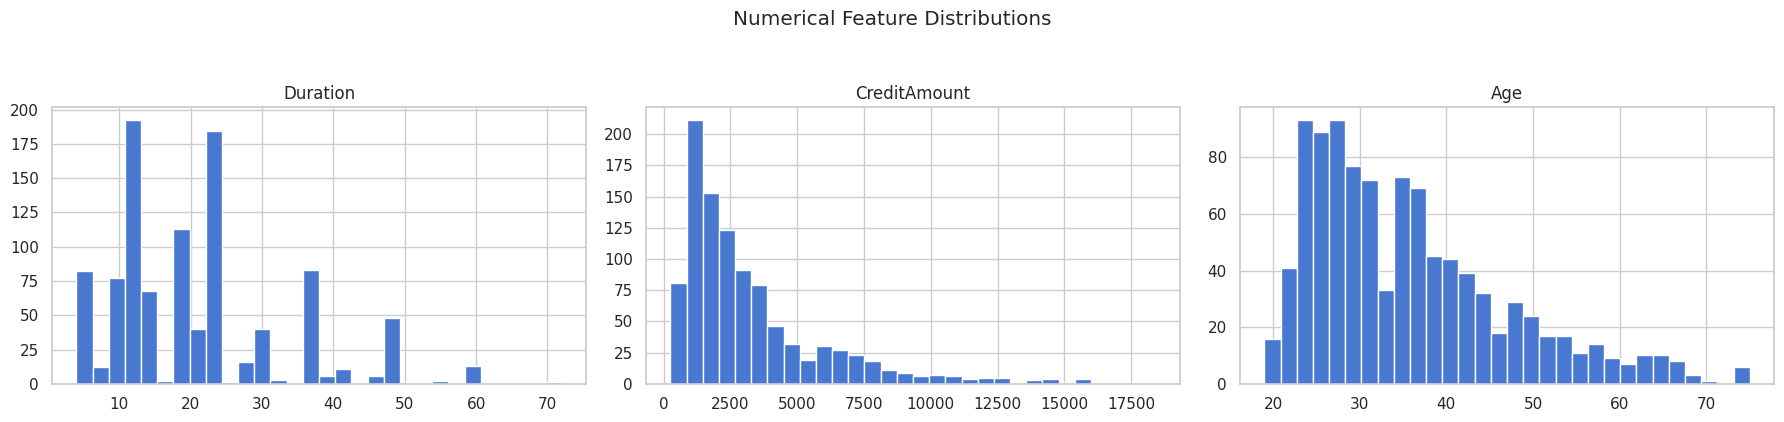

In [ ]:
num_cols = ["Duration", "CreditAmount", "Age"]

df[num_cols].hist(figsize=(18, 4), bins=30, layout=(1, 3))
plt.suptitle("Numerical Feature Distributions", y=1.05)
plt.tight_layout()
plt.show()


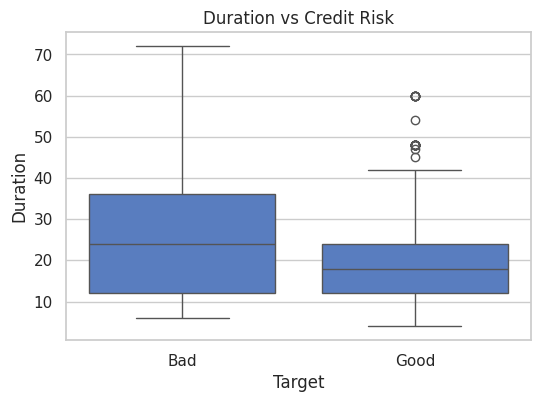

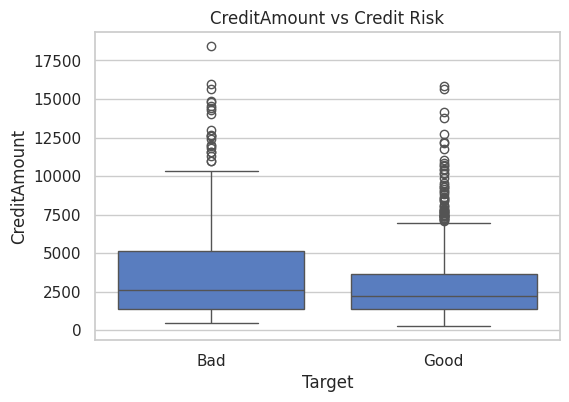

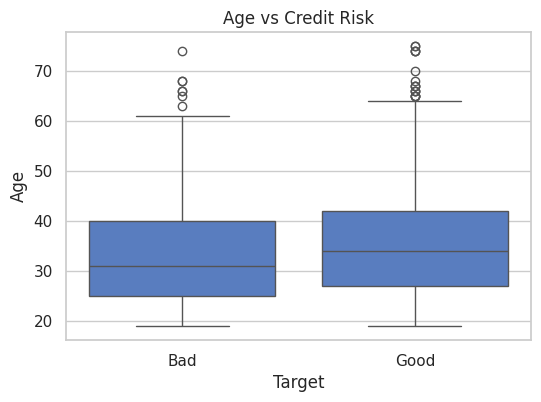

In [ ]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x="Target", y=col, data=df)
    plt.xticks([0,1], ["Bad", "Good"])
    plt.title(f"{col} vs Credit Risk")
    plt.show()


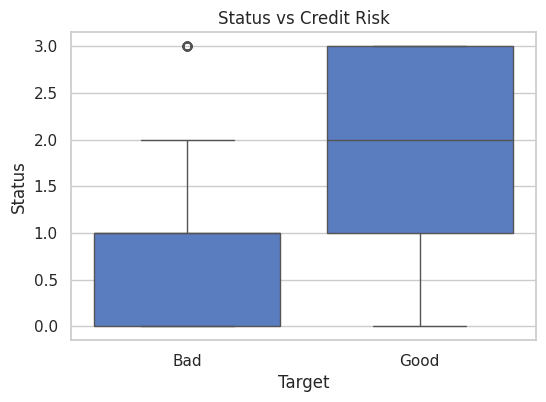

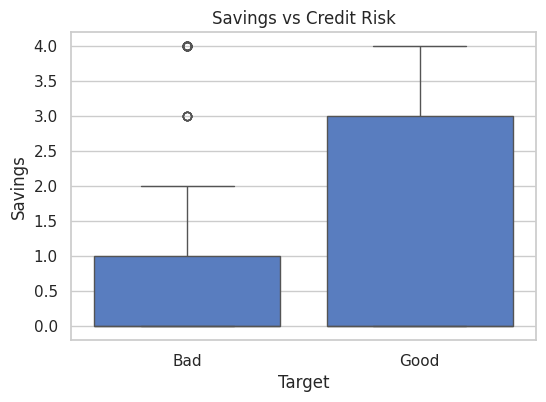

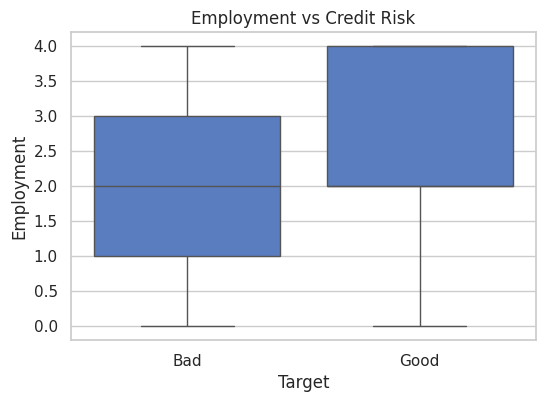

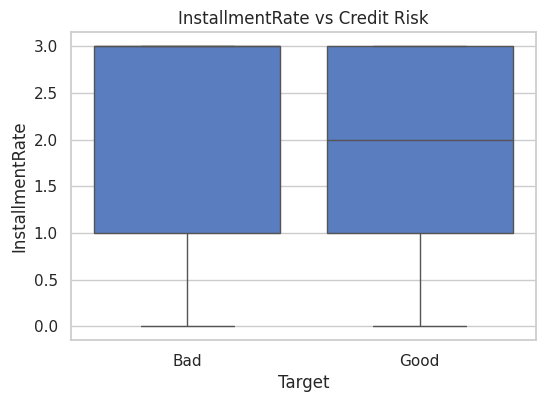

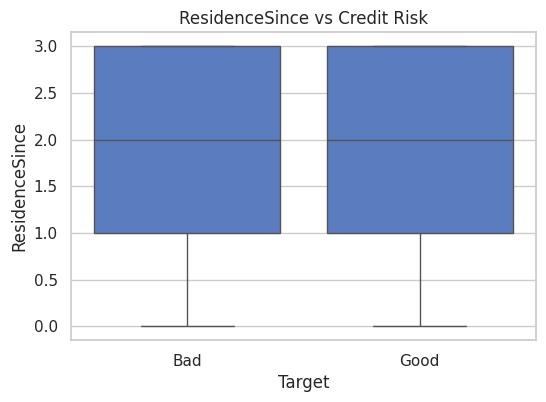

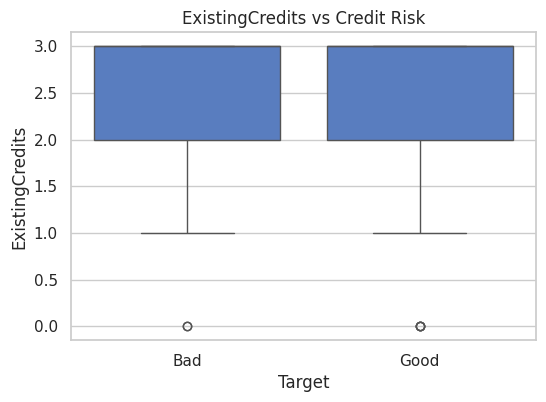

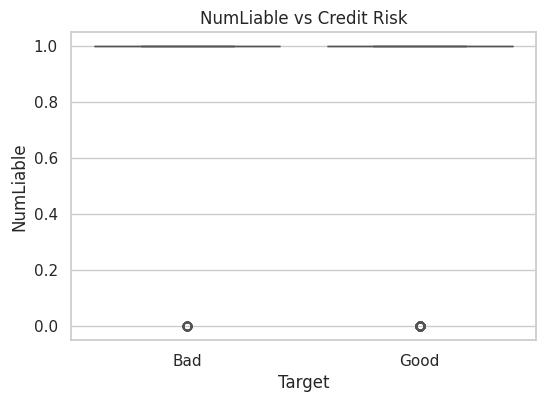

In [ ]:
ordinal_cols = list(ordinal_mappings.keys())

for col in ordinal_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x="Target", y=col, data=df)
    plt.xticks([0,1], ["Bad", "Good"])
    plt.title(f"{col} vs Credit Risk")
    plt.show()


<Figure size 700x400 with 0 Axes>

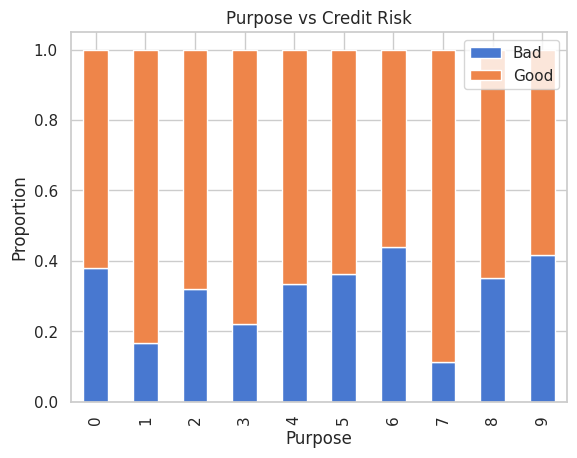

<Figure size 700x400 with 0 Axes>

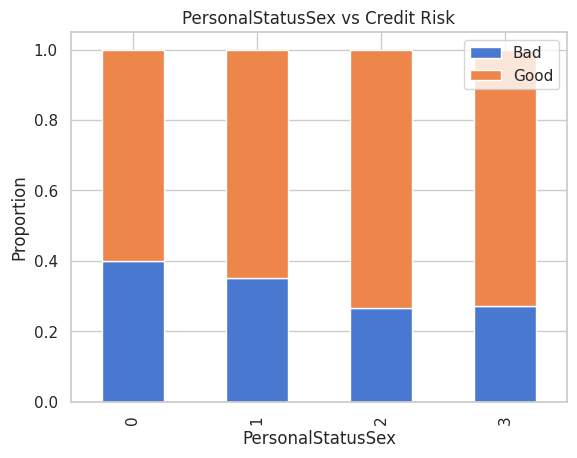

<Figure size 700x400 with 0 Axes>

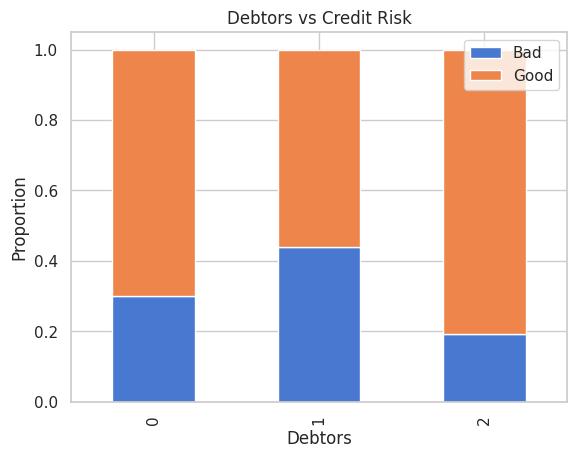

<Figure size 700x400 with 0 Axes>

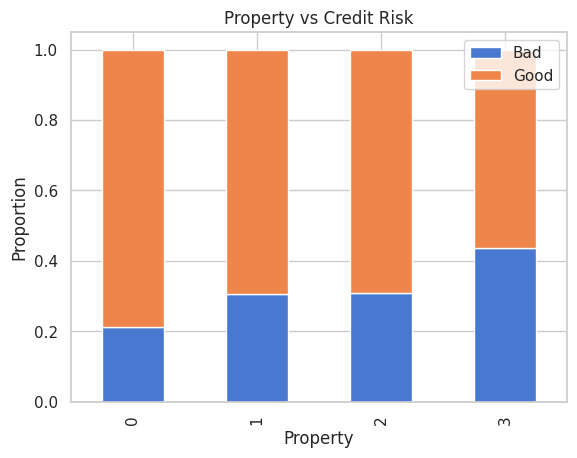

<Figure size 700x400 with 0 Axes>

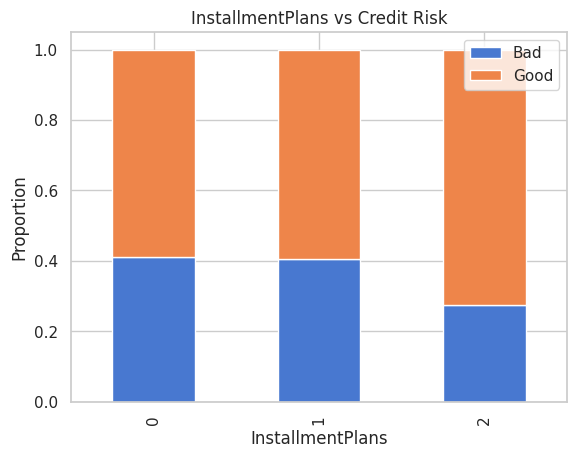

<Figure size 700x400 with 0 Axes>

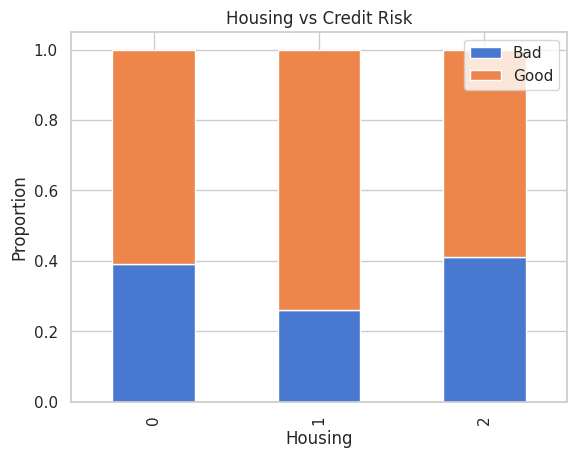

<Figure size 700x400 with 0 Axes>

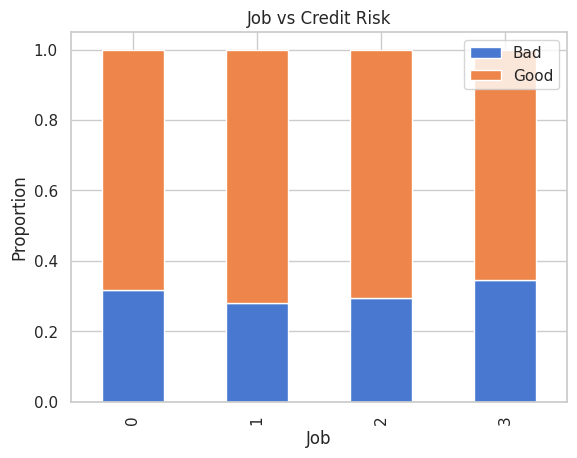

<Figure size 700x400 with 0 Axes>

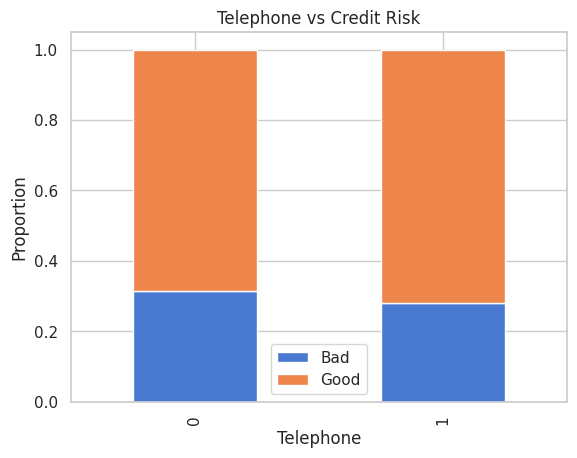

<Figure size 700x400 with 0 Axes>

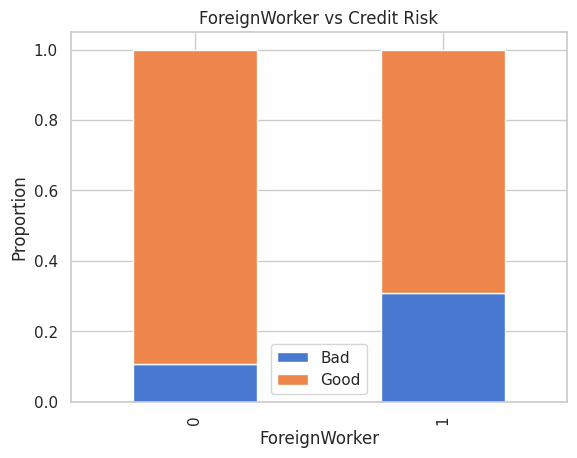

In [ ]:
categorical_cols = ["Purpose", "PersonalStatusSex", "Debtors",
                    "Property", "InstallmentPlans", "Housing",
                    "Job", "Telephone", "ForeignWorker"]

for col in categorical_cols:
    plt.figure(figsize=(7,4))
    pd.crosstab(df[col], df["Target"], normalize="index").plot(kind="bar", stacked=True)
    plt.legend(["Bad", "Good"])
    plt.title(f"{col} vs Credit Risk")
    plt.ylabel("Proportion")
    plt.show()


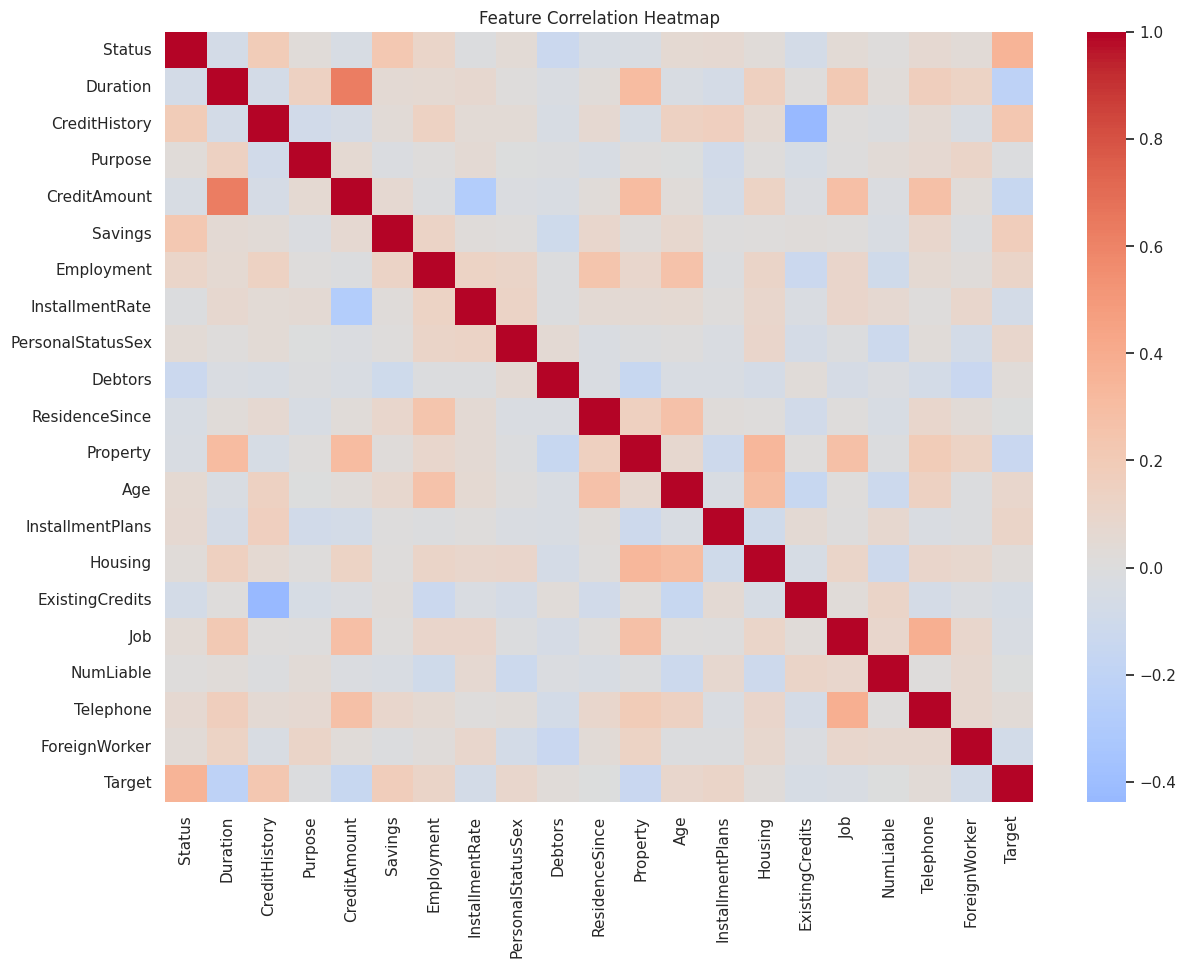

In [ ]:
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(), cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.show()


In [ ]:
df.groupby("Target")[["Duration", "CreditAmount", "Age"]].mean()


,Duration,CreditAmount,Age
Target,,,
0,24.860000,3938.126667,33.96
1,19.207143,2985.442857,36.22


In [ ]:
df.groupby("Target")[ordinal_cols].mean()

,Status,Savings,Employment,InstallmentRate,ResidenceSince,ExistingCredits,NumLiable
Target,,,,,,,
0,0.903333,0.673333,2.170000,2.096667,1.850000,2.633333,0.846667
1,1.865714,1.290000,2.475714,1.920000,1.842857,2.575714,0.844286


#Training

In [8]:
ordinal_mappings = {

    # Checking account status (worst → best)
    'Status': {
        1: 0,   # no checking account
        2: 1,   # < 0 DM
        3: 2,   # 0 <= < 200 DM
        4: 3    # >= 200 DM / salary >= 1 year
    },

    # Savings (worst → best)
    'Savings': {
        1: 0,   # unknown / no savings
        2: 1,   # < 100 DM
        3: 2,   # 100–500 DM
        4: 3,   # 500–1000 DM
        5: 4    # >= 1000 DM
    },

    # Employment duration (worst → best)
    'Employment': {
        1: 0,   # unemployed
        2: 1,   # < 1 year
        3: 2,   # 1–4 years
        4: 3,   # 4–7 years
        5: 4    # >= 7 years
    },

    # Installment burden (worst → best)
    # High percentage = high burden = risky
    'InstallmentRate': {
        1: 0,   # >= 35% (worst)
        2: 1,   # 25–35%
        3: 2,   # 20–25%
        4: 3    # < 20% (best)
    },

    # Residence stability (worst → best)
    'ResidenceSince': {
        1: 0,   # < 1 year
        2: 1,   # 1–4 years
        3: 2,   # 4–7 years
        4: 3    # >= 7 years
    },

    # Number of existing credits (worst → best)
    'ExistingCredits': {
        4: 0,   # >= 6 credits
        3: 1,   # 4–5 credits
        2: 2,   # 2–3 credits
        1: 3    # 1 credit (best)
    },

    # Number of dependents (worst → best)
    'NumLiable': {
        1: 0,   # 3 or more dependents
        2: 1    # 0–2 dependents
    }
}


In [9]:
for col, mapping in ordinal_mappings.items():
  df[col] = df[col].map(mapping)

In [10]:
df.head()

,Status,Duration,CreditHistory,Purpose,CreditAmount,Savings,Employment,InstallmentRate,PersonalStatusSex,Debtors,...,Property,Age,InstallmentPlans,Housing,ExistingCredits,Job,NumLiable,Telephone,ForeignWorker,Target
0,0,18,4,2,1049,0,1,3,2,1,...,2,21,3,1,3,3,1,1,2,1
1,0,9,4,0,2799,0,2,1,3,1,...,1,36,3,1,2,3,0,1,2,1
2,1,12,2,9,841,1,3,1,2,1,...,1,23,3,1,3,2,1,1,2,1
3,0,12,4,0,2122,0,2,2,3,1,...,1,39,3,1,2,2,0,1,1,1
4,0,12,4,0,2171,0,2,3,3,1,...,2,38,1,2,2,2,1,1,1,1


In [11]:
nominal_cols = ["CreditHistory", "Purpose", "PersonalStatusSex", "Debtors", "Property","InstallmentPlans", "Housing", "Job", "Telephone", "ForeignWorker"]

In [12]:
# Save original nominal for linear model encoding
nominal_mapping_audit = {}
for col in nominal_cols:
  df[col] = df[col].astype('category')
  nominal_mapping_audit[col] = dict(enumerate(df[col].cat.categories))
  df[col] = df[col].cat.codes

In [13]:
nominal_mapping_audit

{'CreditHistory': {0: 0, 1: 1, 2: 2, 3: 3, 4: 4},
 'Purpose': {0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5, 6: 6, 7: 8, 8: 9, 9: 10},
 'PersonalStatusSex': {0: 1, 1: 2, 2: 3, 3: 4},
 'Debtors': {0: 1, 1: 2, 2: 3},
 'Property': {0: 1, 1: 2, 2: 3, 3: 4},
 'InstallmentPlans': {0: 1, 1: 2, 2: 3},
 'Housing': {0: 1, 1: 2, 2: 3},
 'Job': {0: 1, 1: 2, 2: 3, 3: 4},
 'Telephone': {0: 1, 1: 2},
 'ForeignWorker': {0: 1, 1: 2}}

In [14]:
df.head()

,Status,Duration,CreditHistory,Purpose,CreditAmount,Savings,Employment,InstallmentRate,PersonalStatusSex,Debtors,...,Property,Age,InstallmentPlans,Housing,ExistingCredits,Job,NumLiable,Telephone,ForeignWorker,Target
0,0,18,4,2,1049,0,1,3,1,0,...,1,21,2,0,3,2,1,0,1,1
1,0,9,4,0,2799,0,2,1,2,0,...,0,36,2,0,2,2,0,0,1,1
2,1,12,2,8,841,1,3,1,1,0,...,0,23,2,0,3,1,1,0,1,1
3,0,12,4,0,2122,0,2,2,2,0,...,0,39,2,0,2,1,0,0,0,1
4,0,12,4,0,2171,0,2,3,2,0,...,1,38,0,1,2,1,1,0,0,1


In [15]:
# Dual Feature Encoding for Linear vs Tree-Based Models
ordinal_cols = list(ordinal_mappings.keys())
numeric_cols = ["Duration", "CreditAmount", "Age"]

In [16]:
X_tree = df.drop("Target", axis=1)
y = df["Target"]

In [17]:
# One-Hot Encode Nominal for Linear Models
df_linear = pd.get_dummies(df, columns=nominal_cols, drop_first=True)
X_linear = df_linear.drop("Target", axis=1)

feature_names_tree = X_tree.columns.tolist()
feature_names_linear = X_linear.columns.tolist()

In [18]:
X_linear

,Status,Duration,CreditAmount,Savings,Employment,InstallmentRate,ResidenceSince,Age,ExistingCredits,NumLiable,...,Property_3,InstallmentPlans_1,InstallmentPlans_2,Housing_1,Housing_2,Job_1,Job_2,Job_3,Telephone_1,ForeignWorker_1
0,0,18,1049,0,1,3,3,21,3,1,...,False,False,True,False,False,False,True,False,False,True
1,0,9,2799,0,2,1,1,36,2,0,...,False,False,True,False,False,False,True,False,False,True
2,1,12,841,1,3,1,3,23,3,1,...,False,False,True,False,False,True,False,False,False,True
3,0,12,2122,0,2,2,1,39,2,0,...,False,False,True,False,False,True,False,False,False,False
4,0,12,2171,0,2,3,3,38,2,1,...,False,False,False,True,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0,24,1987,0,2,1,3,21,3,0,...,False,False,True,False,False,True,False,False,False,True
996,0,24,2303,0,4,3,0,45,3,1,...,False,False,True,True,False,False,True,False,False,True
997,3,21,12680,4,4,3,3,30,3,1,...,True,False,True,False,True,False,False,True,True,True
998,1,12,6468,4,0,1,0,52,3,1,...,True,False,True,True,False,False,False,True,True,True


In [19]:
X_tree

,Status,Duration,CreditHistory,Purpose,CreditAmount,Savings,Employment,InstallmentRate,PersonalStatusSex,Debtors,ResidenceSince,Property,Age,InstallmentPlans,Housing,ExistingCredits,Job,NumLiable,Telephone,ForeignWorker
0,0,18,4,2,1049,0,1,3,1,0,3,1,21,2,0,3,2,1,0,1
1,0,9,4,0,2799,0,2,1,2,0,1,0,36,2,0,2,2,0,0,1
2,1,12,2,8,841,1,3,1,1,0,3,0,23,2,0,3,1,1,0,1
3,0,12,4,0,2122,0,2,2,2,0,1,0,39,2,0,2,1,0,0,0
4,0,12,4,0,2171,0,2,3,2,0,3,1,38,0,1,2,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0,24,2,3,1987,0,2,1,2,0,3,0,21,2,0,3,1,0,0,1
996,0,24,2,0,2303,0,4,3,2,1,0,0,45,2,1,3,2,1,0,1
997,3,21,4,0,12680,4,4,3,2,0,3,3,30,2,2,3,3,1,1,1
998,1,12,2,3,6468,4,0,1,2,0,0,3,52,2,1,3,3,1,1,1


In [20]:
X_train_tree, X_test_tree, y_train, y_test = train_test_split(X_tree, y, test_size=0.2, stratify=y, random_state=42)
X_train_linear, X_test_linear, _, _ = train_test_split(X_linear, y, test_size=0.2, stratify=y, random_state=42)

In [21]:
scaler = StandardScaler()
X_train_linear_scaled = scaler.fit_transform(X_train_linear)
X_test_linear_scaled = scaler.transform(X_test_linear)

#" MODELS"

In [22]:
models = {
"Logistic Regression": LogisticRegression(max_iter=1000),
"Decision Tree": DecisionTreeClassifier(random_state=42),
"Random Forest": RandomForestClassifier(random_state=42),
"MLP": MLPClassifier(max_iter=500, random_state=42),
"XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

In [23]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


In [24]:
cv

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)

In [25]:
def tune_model(model_name):
  def objective(trial):
    if model_name == "Logistic Regression":
      c = trial.suggest_loguniform("C", 1e-3, 10)
      model = LogisticRegression(C=c, max_iter=1000)
      scores = cross_val_score(model, X_linear, y, scoring="roc_auc", cv=5)


    elif model_name == "Decision Tree":
      max_depth = trial.suggest_int("max_depth", 3, 15)
      min_samples_split = trial.suggest_int("min_samples_split", 2, 10)
      model = DecisionTreeClassifier(max_depth=max_depth, min_samples_split=min_samples_split)
      scores = cross_val_score(model, X_tree, y, scoring="roc_auc", cv=5)


    elif model_name == "Random Forest":
      n_estimators = trial.suggest_int("n_estimators", 50, 300)
      max_depth = trial.suggest_int("max_depth", 3, 15)
      max_features = trial.suggest_categorical("max_features", ["sqrt", "log2"])
      model = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth,
      max_features=max_features, random_state=42)
      scores = cross_val_score(model, X_tree, y, scoring="roc_auc", cv=5)

    elif model_name == "MLP":
      hidden_layer_sizes = trial.suggest_categorical("hidden_layer_sizes", [(50,), (100,), (50,50)])
      alpha = trial.suggest_float("alpha", 1e-5, 1e-2, log=True)
      learning_rate_init = trial.suggest_float("learning_rate_init", 0.0001, 0.01, log=True)
      model = MLPClassifier(hidden_layer_sizes=hidden_layer_sizes, alpha=alpha,learning_rate_init=learning_rate_init, max_iter=500, random_state=42)
      scores = cross_val_score(model, X_linear, y, scoring="roc_auc", cv=5)

    elif model_name == "XGBoost":
      param = {
      'max_depth': trial.suggest_int('max_depth', 3, 10),
      'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
      'n_estimators': trial.suggest_int('n_estimators', 50, 300),
      'subsample': trial.suggest_float('subsample', 0.6, 1.0),
      'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
      'eval_metric': 'logloss',
      'use_label_encoder': False,
      'random_state': 42
      }
      model = XGBClassifier(**param)
      scores = cross_val_score(model, X_tree, y, scoring='roc_auc', cv=5)

    return scores.mean()

  study = optuna.create_study(direction="maximize")
  study.optimize(objective, n_trials=20)
  return study.best_params

In [28]:
# Tune all models
model_names = ["Logistic Regression", "Decision Tree", "Random Forest", "MLP", "XGBoost"]
best_params_all = {name: tune_model(name) for name in tqdm(model_names, desc="Tuning All Models")}

Tuning All Models:   0%|          | 0/5 [00:00<?, ?it/s]

[I 2026-01-29 13:40:26,658] A new study created in memory with name: no-name-131709be-4ede-4e4f-a995-b0be796aa5b9
[I 2026-01-29 13:40:34,969] Trial 0 finished with value: 0.7605952380952381 and parameters: {'C': 1.436106889850563}. Best is trial 0 with value: 0.7605952380952381.
[I 2026-01-29 13:40:36,567] Trial 1 finished with value: 0.7693809523809525 and parameters: {'C': 0.0393144644357731}. Best is trial 1 with value: 0.7693809523809525.
[I 2026-01-29 13:40:37,875] Trial 2 finished with value: 0.7673809523809524 and parameters: {'C': 0.18298897991914292}. Best is trial 1 with value: 0.7693809523809525.
[I 2026-01-29 13:40:39,128] Trial 3 finished with value: 0.7619285714285714 and parameters: {'C': 0.6098908573587165}. Best is trial 1 with value: 0.7693809523809525.
[I 2026-01-29 13:40:41,564] Trial 4 finished with value: 0.768 and parameters: {'C': 0.02373448805342327}. Best is trial 1 with value: 0.7693809523809525.
[I 2026-01-29 13:40:43,043] Trial 5 finished with value: 0.7079

In [29]:
#  Train Models with Best Params
models = {
"Logistic Regression": LogisticRegression(**best_params_all["Logistic Regression"], max_iter=1000),
"Decision Tree": DecisionTreeClassifier(**best_params_all["Decision Tree"]),
"Random Forest": RandomForestClassifier(**best_params_all["Random Forest"], random_state=42),
"MLP": MLPClassifier(**best_params_all["MLP"], max_iter=500, random_state=42),
"XGBoost": XGBClassifier(**best_params_all["XGBoost"])
}

In [30]:
best_params_all["Random Forest"]

{'n_estimators': 139, 'max_depth': 11, 'max_features': 'log2'}

In [31]:
trained_models = {}
results = []

for name, model in models.items():

    if name in ["Logistic Regression", "MLP"]:
        model.fit(X_train_linear_scaled, y_train)
        preds = model.predict(X_test_linear_scaled)
        proba = model.predict_proba(X_test_linear_scaled)[:, 1]
        scores = cross_val_score(model, X_linear, y, scoring="roc_auc", cv=cv)

    else:
        model.fit(X_train_tree, y_train)
        preds = model.predict(X_test_tree)
        proba = model.predict_proba(X_test_tree)[:, 1]
        scores = cross_val_score(model, X_tree, y, scoring="roc_auc", cv=cv)

    trained_models[name] = model


    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1": f1_score(y_test, preds),
        "ROC_AUC": roc_auc_score(y_test, proba),
        "CV_ROC_AUC_Mean": scores.mean(),
        "CV_ROC_AUC_Std": scores.std()
    })


In [32]:
results_df = pd.DataFrame(results).sort_values("CV_ROC_AUC_Mean", ascending=False)
# 1. Prevent the 'wrapping' behavior
pd.set_option('display.expand_frame_repr', False)

# 2. Increase the character width allowed per line (e.g., 1000 characters)
pd.set_option('display.width', 1000)

# 3. Ensure all columns are shown (don't hide the middle ones with '...')
pd.set_option('display.max_columns', None)

print(results_df.to_markdown(index=False))


| Model               |   Accuracy |   Precision |   Recall |       F1 |   ROC_AUC |   CV_ROC_AUC_Mean |   CV_ROC_AUC_Std |
|:--------------------|-----------:|------------:|---------:|---------:|----------:|------------------:|-----------------:|
| XGBoost             |      0.79  |    0.822368 | 0.892857 | 0.856164 |  0.83119  |          0.793452 |        0.0423575 |
| Random Forest       |      0.79  |    0.802469 | 0.928571 | 0.860927 |  0.815714 |          0.783262 |        0.0361725 |
| Logistic Regression |      0.785 |    0.808917 | 0.907143 | 0.855219 |  0.840952 |          0.779714 |        0.0412224 |
| MLP                 |      0.765 |    0.82069  | 0.85     | 0.835088 |  0.824762 |          0.747643 |        0.0386351 |
| Decision Tree       |      0.725 |    0.720207 | 0.992857 | 0.834835 |  0.72875  |          0.709298 |        0.0341805 |


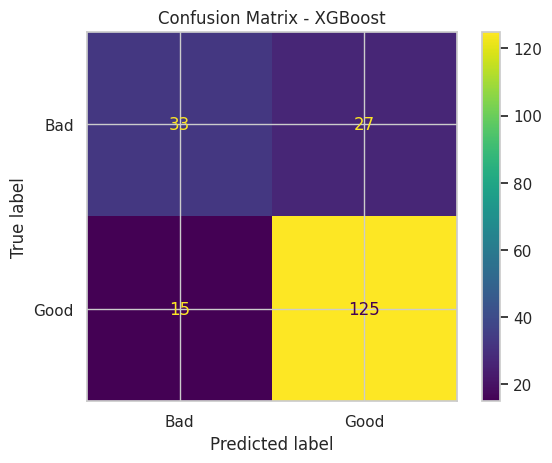

In [33]:
# Confusion Matrix
best_model_name = results_df.iloc[0]['Model']
best_model = trained_models[best_model_name]
X_eval = X_test_linear_scaled if best_model_name in ["Logistic Regression", "MLP"] else X_test_tree
ConfusionMatrixDisplay.from_predictions(
    y_test,
    best_model.predict(X_eval),
    display_labels=["Bad", "Good"]
)

plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

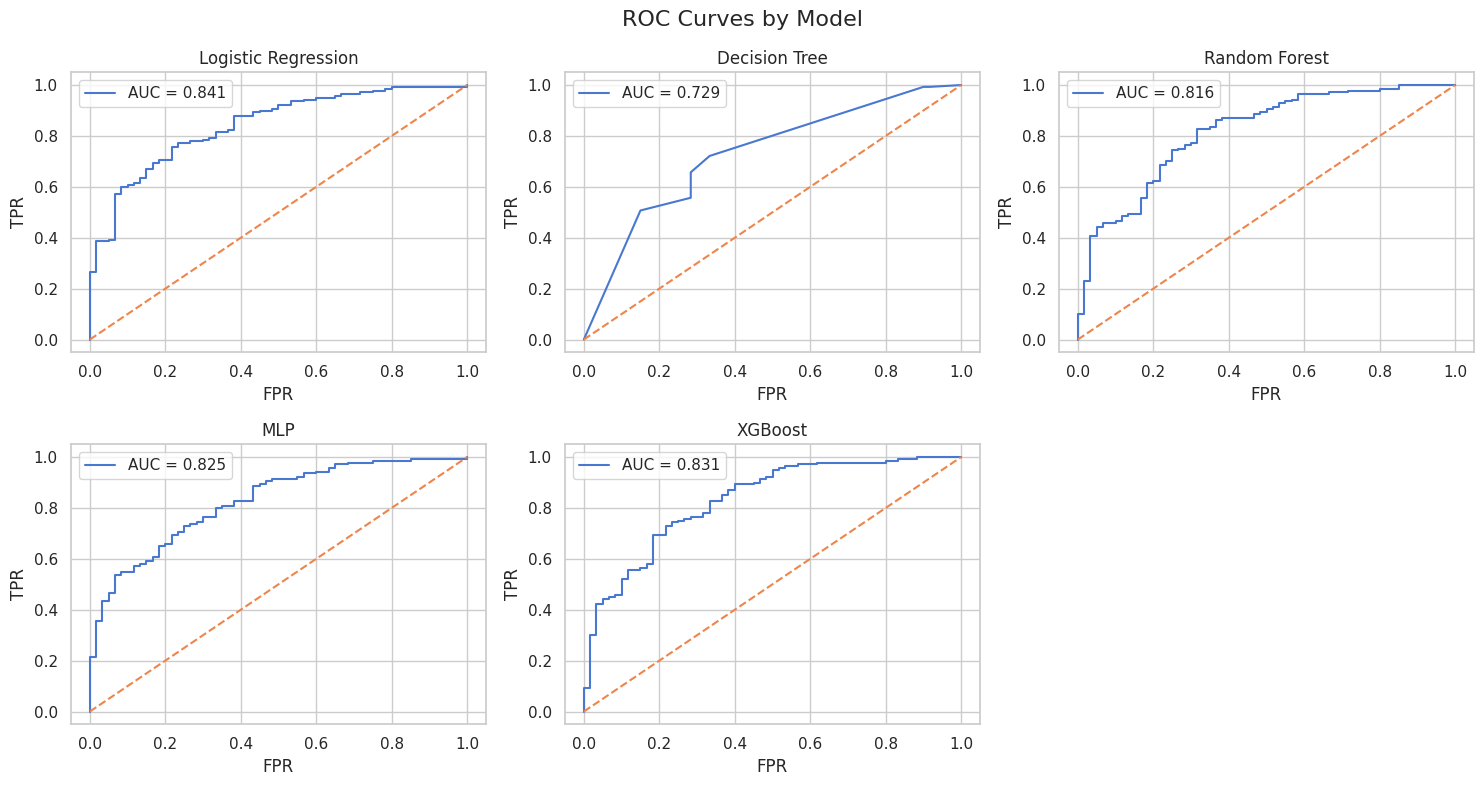

In [35]:

# ROC Curves
from sklearn.metrics import roc_curve, auc
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, (name, model) in zip(axes, trained_models.items()):

    if name in ["Logistic Regression", "MLP"]:
        X_eval_model = X_test_linear_scaled
    else:
        X_eval_model = X_test_tree

    proba = model.predict_proba(X_eval_model)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc = auc(fpr, tpr)

    ax.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    ax.plot([0, 1], [0, 1], "--")
    ax.set_title(name)
    ax.set_xlabel("FPR")
    ax.set_ylabel("TPR")
    ax.legend()
    ax.grid(True)

# Remove empty subplot if odd number of models
for i in range(len(trained_models), len(axes)):
    fig.delaxes(axes[i])

plt.suptitle("ROC Curves by Model", fontsize=16)
plt.tight_layout()
plt.show()


In [36]:
model_to_explain = trained_models["XGBoost"]
X_shap = X_test_tree
shap.initjs()

explainer = shap.TreeExplainer(model_to_explain)
shap_values = explainer.shap_values(X_shap)

# Case 1: shap returns list (one array per class)
if isinstance(shap_values, list):
    good_index = list(model_to_explain.classes_).index(1)
    shap_vals_good = shap_values[good_index]

# Case 2: shap returns 3D array (samples, features, classes)
elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    good_index = list(model_to_explain.classes_).index(1)
    shap_vals_good = shap_values[:, :, good_index]

# Case 3: shap returns 2D array (already the positive class)
else:
    shap_vals_good = shap_values
print("SHAP shape:", shap_vals_good.shape)



SHAP shape: (200, 20)


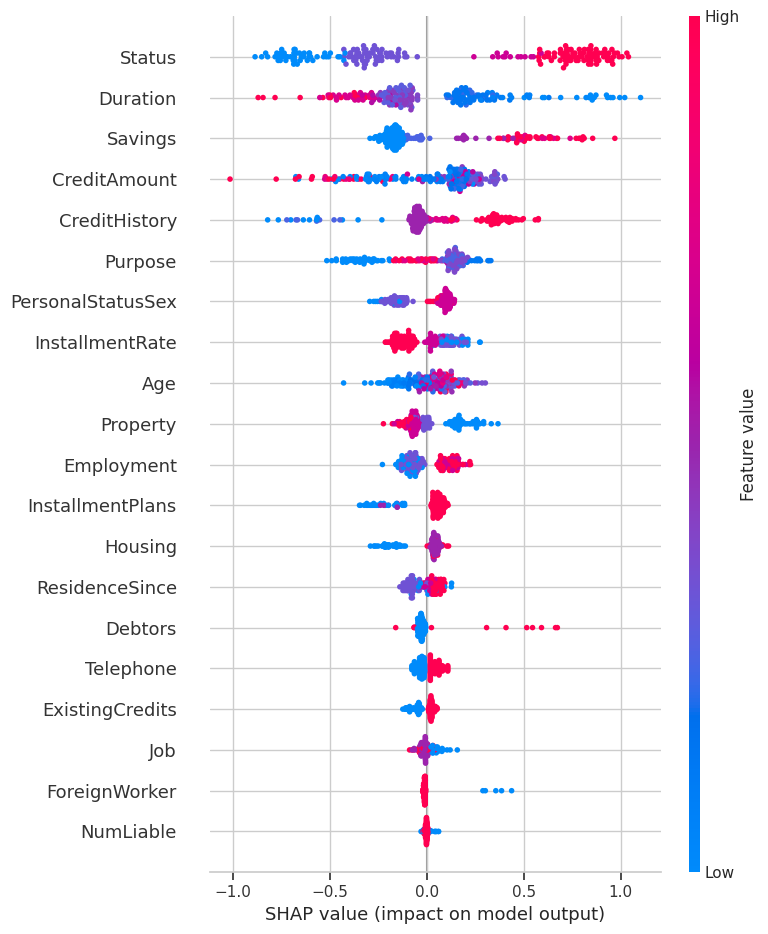

In [37]:
shap.summary_plot(
    shap_vals_good,
    X_shap,
    feature_names=X_shap.columns.tolist()
)


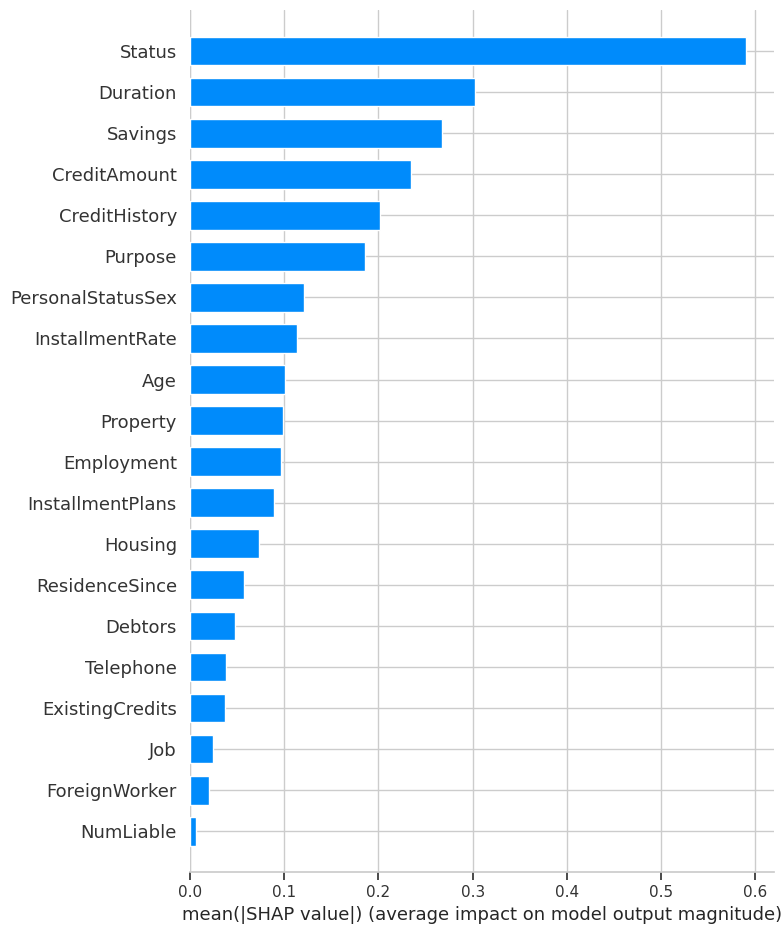

In [38]:
shap.summary_plot(shap_vals_good,X_shap, plot_type="bar", feature_names=X_shap.columns.tolist())


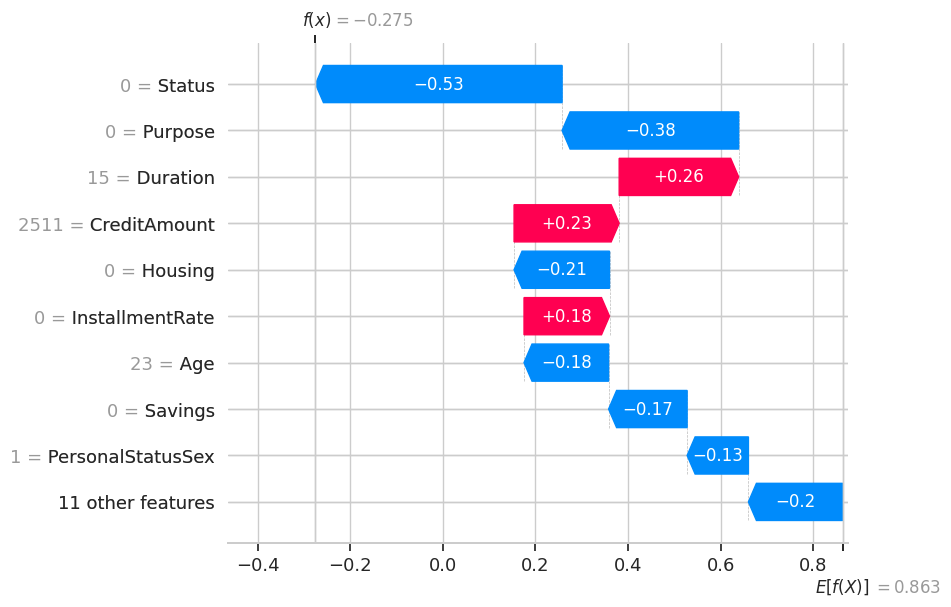

In [39]:

# Build Explanation object for one sample
if isinstance(explainer.expected_value, (list, np.ndarray)):
    base_value = explainer.expected_value[list(model.classes_).index(1)]
else:
    base_value = explainer.expected_value

explanation = shap.Explanation(
    values=shap_vals_good[0],
    base_values=base_value,
    data=X_shap.iloc[0],
    feature_names=X_shap.columns
)

shap.plots.waterfall(explanation)

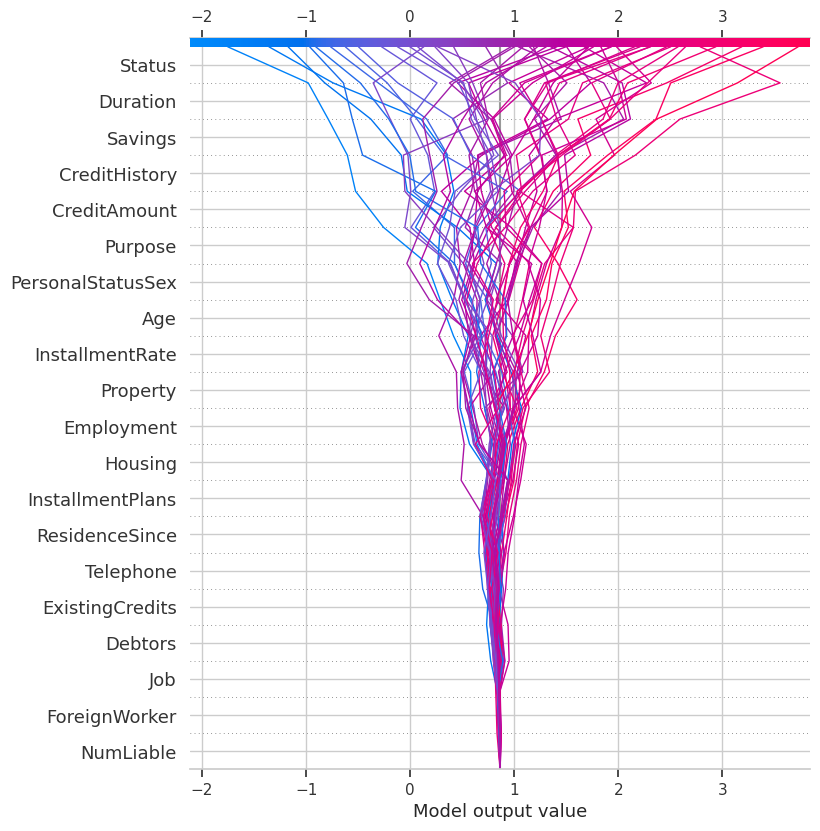

In [40]:

# SHAP Decision Plot

# Base value for positive class
if isinstance(explainer.expected_value, (list, np.ndarray)):
    base_value = explainer.expected_value[list(model_to_explain.classes_).index(1)]
else:
    base_value = explainer.expected_value

# Decision plot for first 50 test samples
shap.decision_plot(
    base_value,
    shap_vals_good[:50],
    X_shap.iloc[:50],
    feature_names=X_shap.columns.tolist()
)



LIME Explanation (Feature, Impact):

CreditHistory <= 2.00                -0.107
Status <= 0.00                       -0.100
Purpose <= 1.00                      -0.094
Savings <= 0.00                      -0.084
PersonalStatusSex <= 1.00            -0.070
2281.50 < CreditAmount <= 3907.50    +0.058
InstallmentRate <= 1.00              +0.057
Employment <= 2.00                   -0.051
1.00 < Property <= 2.00              -0.039
Housing <= 1.00                      -0.029


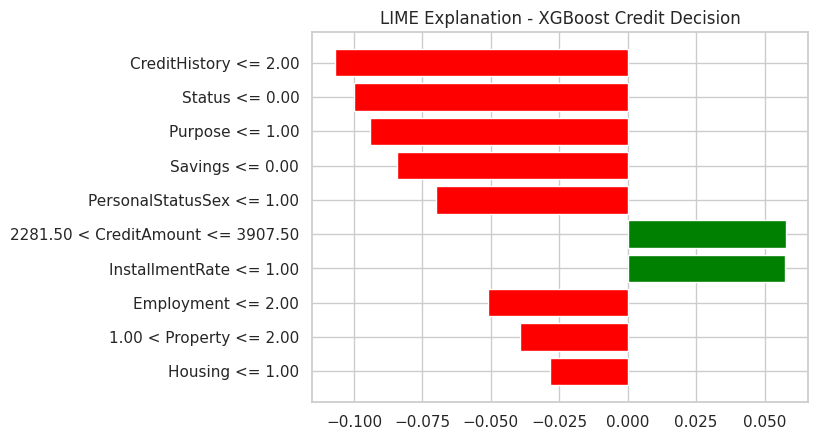


Model prediction:
Bad Credit Probability : 0.568
Good Credit Probability: 0.432


In [47]:

# LIME for XGBoost


xgb_model = trained_models["XGBoost"]


# LIME Explainer
explainer_lime = LimeTabularExplainer(
    training_data = X_train_tree.values,
    feature_names = X_train_tree.columns.tolist(),
    class_names = ["Bad Credit", "Good Credit"],  # 0 = bad, 1 = good
    mode = "classification",
    discretize_continuous = True
)

# Explain ONE customer
i = 0   # change index to explain different customers

exp = explainer_lime.explain_instance(
    data_row = X_test_tree.iloc[i].values,
    predict_fn = xgb_model.predict_proba,
    num_features = 10
)
# Show explanation
print("\nLIME Explanation (Feature, Impact):\n")
for feature, weight in exp.as_list():
    print(f"{feature:35s}  {weight:+.3f}")

# Interactive notebook view
exp.show_in_notebook(show_table=True)


fig = exp.as_pyplot_figure()
plt.title("LIME Explanation - XGBoost Credit Decision")
plt.show()

# Show prediction probability
proba = xgb_model.predict_proba(X_test_tree.iloc[[i]])[0]

print("\nModel prediction:")
print(f"Bad Credit Probability : {proba[0]:.3f}")
print(f"Good Credit Probability: {proba[1]:.3f}")


In [44]:
# =========================
# Bias & Fairness Audit
# =========================

preds_audit = best_model.predict(X_eval)
proba_audit = best_model.predict_proba(X_eval)[:, 1]

audit_df = pd.DataFrame(
    index=X_eval.index,
    data={
        "Prediction": preds_audit,
        "Good_Prob": proba_audit,
        "PersonalStatusSex": df.loc[X_eval.index, "PersonalStatusSex"],
        "ForeignWorker": df.loc[X_eval.index, "ForeignWorker"],
        "Age": df.loc[X_eval.index, "Age"]
    }
)

print("Approval rate by PersonalStatusSex:")
print(audit_df.groupby("PersonalStatusSex")["Prediction"].mean())

print("\nApproval rate by Foreign Worker status:")
print(audit_df.groupby("ForeignWorker")["Prediction"].mean())

audit_df["AgeGroup"] = pd.cut(
    audit_df["Age"],
    bins=[18,25,35,50,100],
    labels=["18–25","26–35","36–50","50+"]
)

print("\nAverage approval probability by Age Group:")
print(audit_df.groupby("AgeGroup")["Good_Prob"].mean())

Approval rate by PersonalStatusSex:
PersonalStatusSex
0    0.923077
1    0.612903
2    0.820755
3    0.789474
Name: Prediction, dtype: float64

Approval rate by Foreign Worker status:
ForeignWorker
0    0.800000
1    0.758974
Name: Prediction, dtype: float64

Average approval probability by Age Group:
AgeGroup
18–25    0.537222
26–35    0.687632
36–50    0.765480
50+      0.832733
Name: Good_Prob, dtype: float32


In [45]:

# Age Group Bias Check

audit_df["AgeGroup"] = pd.cut(
    audit_df["Age"],
    bins=[18, 25, 35, 50, 100],
    labels=["18–25", "26–35", "36–50", "50+"]
)

print("\nApproval rate by Age Group:")
print(audit_df.groupby("AgeGroup")["Prediction"].mean())

print("\nAverage approval probability by Age Group:")
print(audit_df.groupby("AgeGroup")["Good_Prob"].mean())



Approval rate by Age Group:
AgeGroup
18–25    0.459459
26–35    0.776471
36–50    0.868852
50+      0.941176
Name: Prediction, dtype: float64

Average approval probability by Age Group:
AgeGroup
18–25    0.537222
26–35    0.687632
36–50    0.765480
50+      0.832733
Name: Good_Prob, dtype: float32


In [ ]:

# SHAP-Based Bias Audit

shap_bias_df = pd.DataFrame(
    index=X_eval.index,
    data={
        "SHAP_Total": shap_vals_good.sum(axis=1),
        "PersonalStatusSex": df.loc[X_eval.index, "PersonalStatusSex"],
        "ForeignWorker": df.loc[X_eval.index, "ForeignWorker"]
    }
)

print("Mean SHAP contribution by PersonalStatusSex:")
print(shap_bias_df.groupby("PersonalStatusSex")["SHAP_Total"].mean())

print("\nMean SHAP contribution by ForeignWorker:")
print(shap_bias_df.groupby("ForeignWorker")["SHAP_Total"].mean())


Mean SHAP contribution by PersonalStatusSex:
PersonalStatusSex
0    0.088808
1   -0.109398
2    0.439424
3    0.328057
Name: SHAP_Total, dtype: float32

Mean SHAP contribution by ForeignWorker:
ForeignWorker
0    0.182148
1    0.237298
Name: SHAP_Total, dtype: float32


In [42]:

# Counterfactual Analysis


x_cf = X_eval.iloc[0].copy()

# Baseline approval probability
base_prob = best_model.predict_proba(x_cf.to_frame().T)[0, 1]

# Hypothetical improvement (bounded by max values)
x_cf["Savings"] = min(x_cf["Savings"] + 1, X_tree["Savings"].max())
x_cf["Status"] = min(x_cf["Status"] + 1, X_tree["Status"].max())

# New approval probability
new_prob = best_model.predict_proba(x_cf.to_frame().T)[0, 1]

print(f"Original approval probability: {base_prob:.3f}")
print(f"After improving Savings & Status: {new_prob:.3f}")

Original approval probability: 0.432
After improving Savings & Status: 0.475
